# Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "cars.csv"
df = pd.read_csv(path)

# 2. Initial inspection
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 3981 entries, 0 to 3980
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3981 non-null   int64  
 1   Date                  3981 non-null   str    
 2   Location ID           3981 non-null   str    
 3   Location Description  3981 non-null   str    
 4   Region                3981 non-null   str    
 5   Country               3981 non-null   str    
 6   Latitude              3981 non-null   float64
 7   Longitude             3981 non-null   float64
 8   Area Type             3981 non-null   str    
 9   Junction Control      3981 non-null   str    
 10  Accident Severity     3981 non-null   str    
 11  Time of Day           3981 non-null   str    
 12  Road Conditions       3981 non-null   str    
 13  Junction Detail       3981 non-null   str    
 14  Driver Age            3981 non-null   str    
 15  Sex of Driver         3981 non-n

,ID,Date,Location ID,Location Description,Region,Country,Latitude,Longitude,Area Type,Junction Control,...,Road Conditions,Junction Detail,Driver Age,Sex of Driver,Vehicle Type,Vehicle Propulsion,Number of Accidents,Number of Casualties,Number of Vehicles,Accidental Costs
0,1,2017.Jan,UK01,Birmingham,West Midlands,United Kingdom,52.478609,-1.884923,Urban,Uncontrolled Junction,...,Wet Road,Not at junction,26-35,Male,Car,Petrol,1,1,2,2643.44
1,3,2017.Jan,UK03,Manchester,North West England,United Kingdom,53.481548,-2.245805,Small Town,Traffic Enforcer,...,Snow,Roundabout,Over 56,Female,Motorcycle,Hybrid Electric,1,11,2,1847.23
2,4,2017.Jan,UK04,Westminster,London,United Kingdom,51.497716,-0.135175,Rural,Stop Sign,...,Icy,Crossroad,Over 56,Female,Bus,Heavy Oil,1,1,2,2269.18
3,5,2017.Jan,UK05,Bradford,Yorkshire and the Humber,United Kingdom,53.795548,-1.758909,Small Town,Stop Sign,...,Icy,Roundabout,Over 56,Female,Motorcycle,Heavy Oil,1,1,2,1633.98
4,7,2017.Jan,UK01,Birmingham,West Midlands,United Kingdom,52.478609,-1.884923,Rural,Stop Sign,...,Icy,Crossroad,Over 56,Female,Bus,Heavy Oil,1,1,2,1716.33


In [2]:
print(df.columns.tolist())

['ID', 'Date', 'Location ID', 'Location Description', 'Region', 'Country', 'Latitude', 'Longitude', 'Area Type', 'Junction Control', 'Accident Severity', 'Time of Day', 'Road Conditions', 'Junction Detail', 'Driver Age', 'Sex of Driver', 'Vehicle Type', 'Vehicle Propulsion', 'Number of Accidents', 'Number of Casualties', 'Number of Vehicles', 'Accidental Costs']


# A. Distribution of Accident Severity

/var/folders/17/f959y3w51nz58xljg39gml180000gn/T/ipykernel_35263/1414994825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Accident Severity', data=df, palette='viridis')


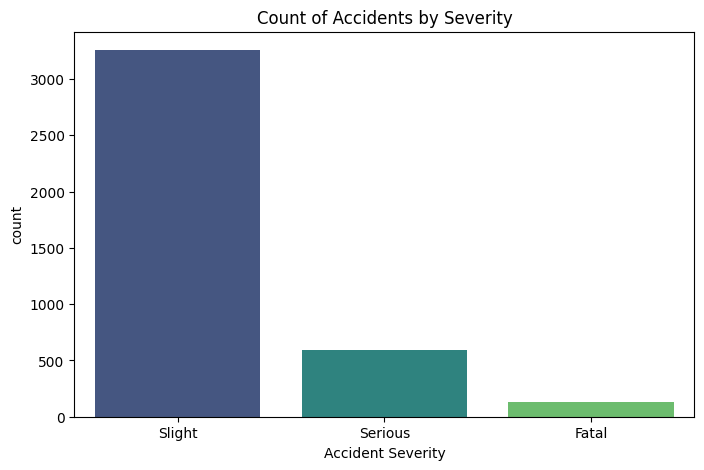

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Accident Severity', data=df, palette='viridis')
plt.title('Count of Accidents by Severity')
plt.show()

# 2. Accidents by Time of Day

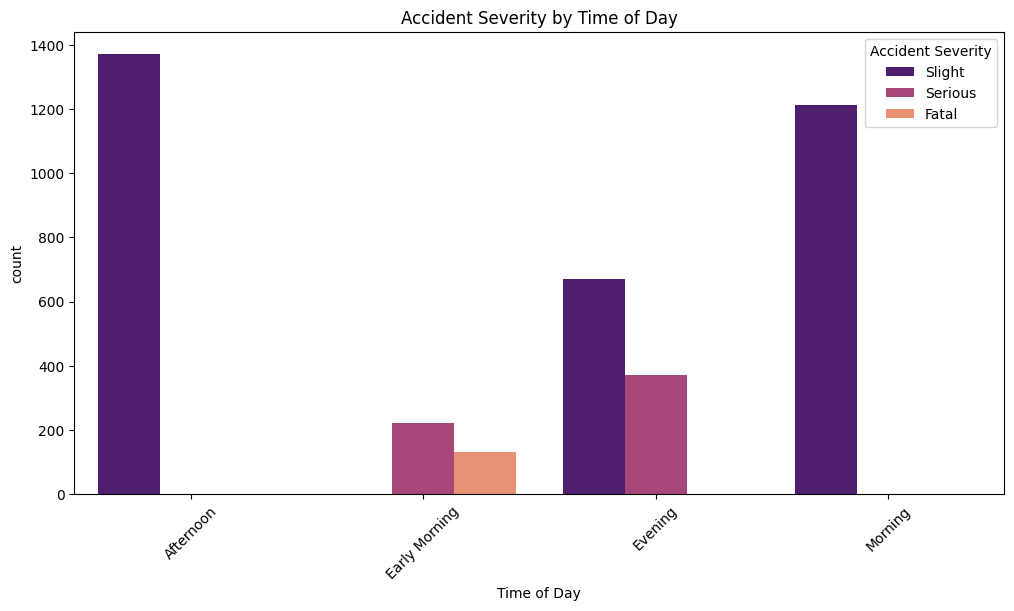

In [4]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Time of Day', hue='Accident Severity', palette='magma')
plt.title('Accident Severity by Time of Day')
plt.xticks(rotation=45)
plt.show()

# 3. Accidents by Road Condition

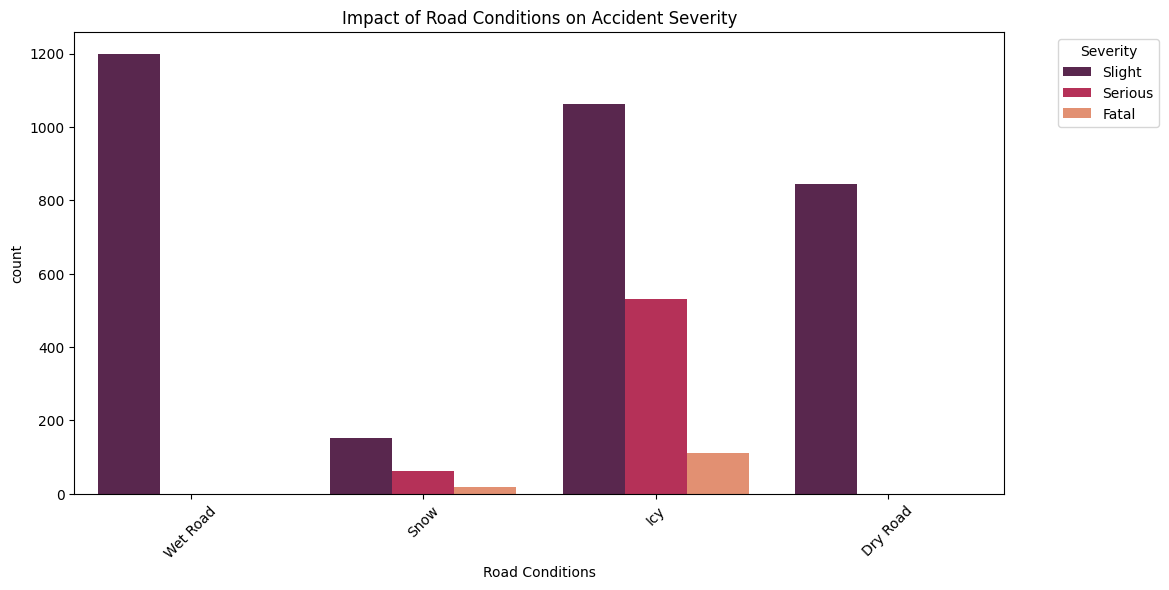

In [5]:
# 3. Road Conditions vs. Severity
# This reveals if slippery or wet roads lead to more dangerous crashes
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Road Conditions', hue='Accident Severity', palette='rocket')
plt.title('Impact of Road Conditions on Accident Severity')
plt.xticks(rotation=45)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 4. Correlation between Number of Vehicles and Number of Casualties

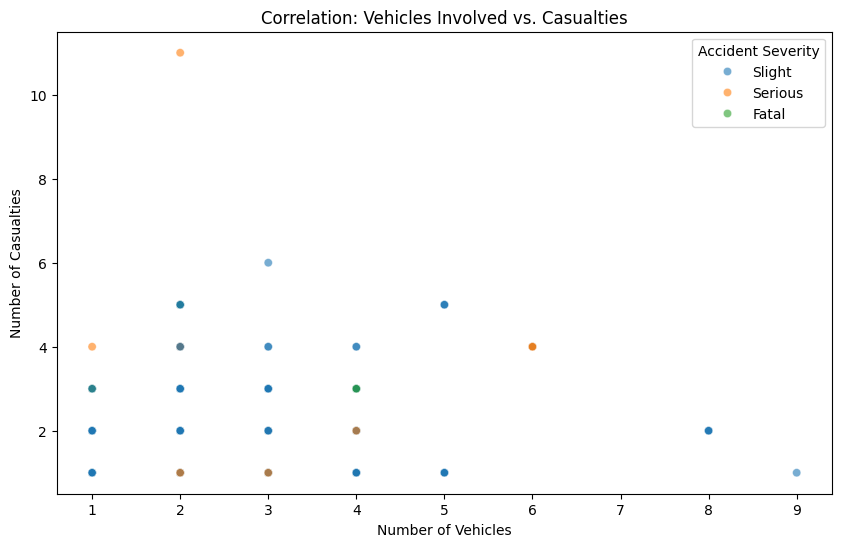

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Number of Vehicles', y='Number of Casualties', hue='Accident Severity', alpha=0.6)
plt.title('Correlation: Vehicles Involved vs. Casualties')
plt.show()

# 5. Preprocess Training Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Selection based on your provided list
features = ['Region', 'Area Type', 'Road Conditions', 'Time of Day',
            'Driver Age', 'Sex of Driver', 'Vehicle Type', 'Number of Vehicles']

X = df[features].copy()
y = df['Accident Severity']

# 2. Handling Categorical Data
le = LabelEncoder()

# Encode features (X)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Encode target (y)
y = le.fit_transform(y.astype(str))

# 3. Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Preprocessing complete. Target classes encoded as:", le.classes_)

Preprocessing complete. Target classes encoded as: ['Fatal' 'Serious' 'Slight']


/var/folders/17/f959y3w51nz58xljg39gml180000gn/T/ipykernel_35263/1534976453.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


# 6. Graph Preprocess Training Data

--- Classification Report ---
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00        25
     Serious       0.69      0.91      0.79       118
      Slight       0.98      0.97      0.97       654

    accuracy                           0.93       797
   macro avg       0.56      0.62      0.59       797
weighted avg       0.91      0.93      0.92       797



/Users/macbookairm1/Documents/Projects/web-dev/UkCarsAccidentAnalysis/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macbookairm1/Documents/Projects/web-dev/UkCarsAccidentAnalysis/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/macbookairm1/Documents/Projects/web-dev/UkCarsAccidentAnalysis/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with 

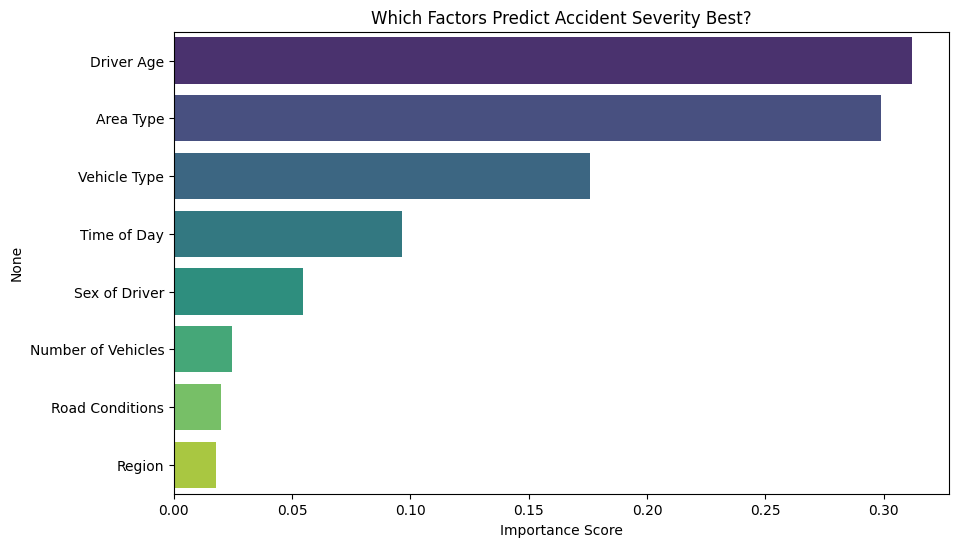

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize and Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 2. Prediction
y_pred = model.predict(X_test)

# 3. Evaluation
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 4. Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Which Factors Predict Accident Severity Best?')
plt.xlabel('Importance Score')
plt.show()

# Test Predictions

In [ ]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Current Model Mapping: {mapping}")

def predict_accident_severity_final(region, area, road, time, age, sex, v_type, n_vehicles):
    test_df = pd.DataFrame([{
        'Region': region, 'Area Type': area, 'Road Conditions': road,
        'Time of Day': time, 'Driver Age': age, 'Sex of Driver': sex,
        'Vehicle Type': v_type, 'Number of Vehicles': n_vehicles
    }])

    for col in test_df.select_dtypes(include=['object']).columns:
        test_df[col] = pd.Categorical(test_df[col], categories=df[col].unique()).codes

        test_df[col] = test_df[col].replace(-1, 0)

    # Predict
    pred_num = model.predict(test_df)[0]
    pred_label = le.inverse_transform([pred_num])[0]

    # Probability
    prob = model.predict_proba(test_df)[0]

    print(f"Predicted Severity: {pred_label}")
    print(f"Confidence: {max(prob)*100:.2f}%")

# Input Here
predict_accident_severity_final('West Midlands', 'Rural', 'Dry Road', 'Morning', 80, 'Female', 'Car', 2)

# Group by Region and sum the total number of accidents

In [10]:
most_accidents_by_region = df.groupby('Region')['Number of Accidents'].sum().sort_values(ascending=False)
most_accidents_by_area_type = df.groupby('Area Type')['Number of Accidents'].sum().sort_values(ascending=False)

print("Top Regions with the most accidents:")
print(most_accidents_by_region.head(10))

print(' ')

print("Top Area Type with the most accidents:")
print(most_accidents_by_area_type)

Top Regions with the most accidents:
Region
Yorkshire and the Humber    1318
North West England          1000
London                       996
West Midlands                667
Name: Number of Accidents, dtype: int64
 
Top Area Type with the most accidents:
Area Type
Urban         2747
Rural          727
Small Town     507
Name: Number of Accidents, dtype: int64
